In [4]:
"""
hz_migration.py  —  Discussion (Section 4.2), Figure 6
--------------------------------------------------------------------------
During the giant phases the host's luminosity rises and the habitable zone
(HZ) migrates outward. A planet that was too distant and cold to be habitable
on the main sequence is therefore swept into the HZ, where it can remain for
~10^8 yr. This motivates the scenario in which surface life arises on an
initially distant world, which may later be delivered to a close, observable
white-dwarf orbit by dynamical scattering (discussed in the text).

Inputs : MIST v2.5 track 00100M_track.eep (1 Msun), parsed directly.
HZ     : approximated by the zero-albedo equilibrium-temperature range
         273-373 K (liquid-water surface, T_eq = [L/(16 pi sigma a^2)]^(1/4)).
Residence time : longest CONTINUOUS interval a planet spends in the HZ; this
         definition handles the RGB-tip / He-flash luminosity excursion, during
         which the HZ briefly retreats inward before resuming its outward march.
Output : hz_migration.png  (two panels: HZ band over time; residence time vs a)
"""


"\nhz_migration.py  —  Discussion (Section 4.2), Figure 6\n--------------------------------------------------------------------------\nDuring the giant phases the host's luminosity rises and the habitable zone\n(HZ) migrates outward. A planet that was too distant and cold to be habitable\non the main sequence is therefore swept into the HZ, where it can remain for\n~10^8 yr. This motivates the scenario in which surface life arises on an\ninitially distant world, which may later be delivered to a close, observable\nwhite-dwarf orbit by dynamical scattering (discussed in the text).\n\nInputs : MIST v2.5 track 00100M_track.eep (1 Msun), parsed directly.\nHZ     : approximated by the zero-albedo equilibrium-temperature range\n         273-373 K (liquid-water surface, T_eq = [L/(16 pi sigma a^2)]^(1/4)).\nResidence time : longest CONTINUOUS interval a planet spends in the HZ; this\n         definition handles the RGB-tip / He-flash luminosity excursion, during\n         which the HZ briefly

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

Lsun = 3.828e26          # W
au   = 1.496e11          # m
sb   = constants.Stefan_Boltzmann



# --- load 1 Msun post-MS window (RGB onset -> EAGB end) ---
d = np.genfromtxt('C:\\Users\\user\\Desktop\\Teff data\\00100M.track.eep', comments='#')
age, logL, ph = d[:, 0], d[:, 6], d[:, -1].astype(int)
i0 = np.where(ph == 2)[0][0]
i1 = np.where(ph == 4)[0][-1]
sl = slice(i0, i1 + 1)
age, L = age[sl], 10**logL[sl]
t = (age - age[0]) / 1e6                       # Myr from post-MS onset

# --- HZ boundaries: distance at which T_eq = 373 K (inner) and 273 K (outer) ---
def a_of_Teq(L_Lsun, Teq):
    return np.sqrt(L_Lsun * Lsun / (16 * np.pi * sb * Teq**4)) / au
hz_in  = a_of_Teq(L, 373.0)
hz_out = a_of_Teq(L, 273.0)



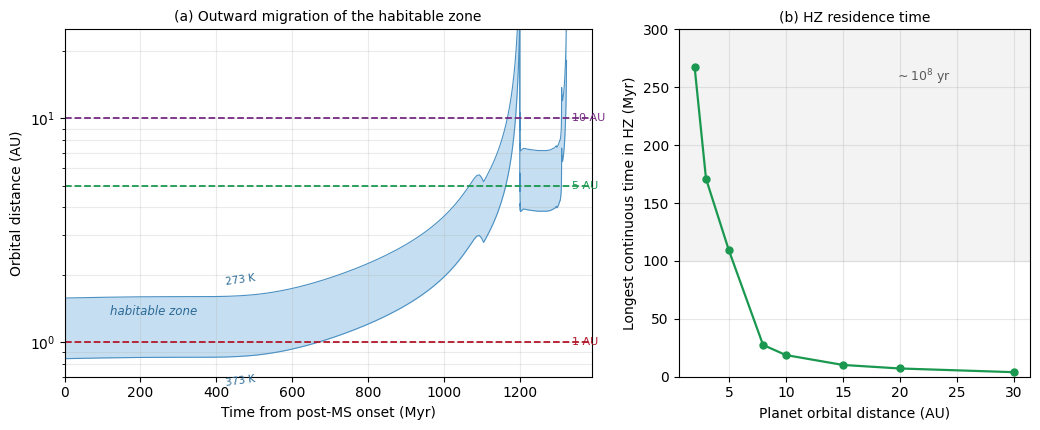

Longest continuous HZ residence:
   2 AU :   268 Myr
   3 AU :   171 Myr
   5 AU :   109 Myr
   8 AU :    27 Myr
  10 AU :    19 Myr
  15 AU :    10 Myr
  20 AU :     7 Myr
  30 AU :     4 Myr

HZ at onset : 0.84-1.57 AU
HZ at end   : 18.2-33.9 AU


In [6]:
# --- longest continuous residence in HZ for a planet at fixed distance a_pl ---
def longest_residence(a_pl):
    Teq = (L * Lsun / (16 * np.pi * sb * (a_pl * au)**2))**0.25
    in_hz = (Teq >= 273) & (Teq <= 373)
    runs, ts, te = [], None, None
    for j in range(len(in_hz)):
        if in_hz[j]:
            if ts is None:
                ts = t[j]
            te = t[j]
        elif ts is not None:
            runs.append(te - ts); ts = None
    if ts is not None:
        runs.append(te - ts)
    return max(runs) if runs else 0.0

C_HZ, C_RED, C_GRN, C_PUR = '#add0ec', '#b2182b', '#1a9850', '#762a83'

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.5, 4.4),
                               gridspec_kw={'width_ratios': [1.5, 1]})

# ---- (a) HZ band over time + example planet orbits (tight y-range) ----
axL.fill_between(t, hz_in, hz_out, color=C_HZ, alpha=0.7, lw=0)
axL.plot(t, hz_in,  color='#4a90c2', lw=0.8)
axL.plot(t, hz_out, color='#4a90c2', lw=0.8)
j = np.argmin(abs(t - t[-1] * 0.32))
axL.text(t[-1]*0.32, hz_in[j]*0.74,  '373 K', fontsize=7.5, color='#2c6a96', rotation=8)
axL.text(t[-1]*0.32, hz_out[j]*1.12, '273 K', fontsize=7.5, color='#2c6a96', rotation=8)
axL.text(120, 1.32, 'habitable zone', fontsize=8.5, color='#2c6a96', style='italic')
for a_pl, c, lab in [(1, C_RED, '1 AU'), (5, C_GRN, '5 AU'), (10, C_PUR, '10 AU')]:
    axL.axhline(a_pl, color=c, lw=1.3, ls='--')
    axL.text(t[-1]*1.01, a_pl, lab, color=c, fontsize=8, va='center')
axL.set_yscale('log')
axL.set_ylim(0.7, 25)                          # tight: focus on the HZ band
axL.set_xlim(0, t[-1] * 1.05)
axL.set_xlabel('Time from post-MS onset (Myr)')
axL.set_ylabel('Orbital distance (AU)')
axL.set_title('(a) Outward migration of the habitable zone', fontsize=10)
axL.grid(alpha=0.25, which='both')

# ---- (b) longest continuous residence vs orbital distance ----
dists = np.array([2, 3, 5, 8, 10, 15, 20, 30])
res = np.array([longest_residence(a) for a in dists])
axR.plot(dists, res, 'o-', color=C_GRN, lw=1.6, ms=5)
axR.axhspan(100, 300, color='0.92', alpha=0.6, zorder=0)
axR.text(22, 255, r'$\sim$10$^8$ yr', fontsize=9, color='0.35', ha='center')
axR.set_xlabel('Planet orbital distance (AU)')
axR.set_ylabel('Longest continuous time in HZ (Myr)')
axR.set_title('(b) HZ residence time', fontsize=10)
axR.set_ylim(0, 300)
axR.grid(alpha=0.3)

fig.tight_layout()
plt.show()

# console summary
print("Longest continuous HZ residence:")
for a, r in zip(dists, res):
    print(f"  {a:2d} AU : {r:5.0f} Myr")
print(f"\nHZ at onset : {hz_in[0]:.2f}-{hz_out[0]:.2f} AU")
print(f"HZ at end   : {hz_in[-1]:.1f}-{hz_out[-1]:.1f} AU")